# Chapter 7: AI Agents for Genomics and Variant Interpretation

## Hands-On Jupyter Notebook

This notebook implements a compact agentic workflow for genomics interpretation using synthetic oncology cases.

**Time to Complete**: 1-2 hours

**What You Will Build**
- A synthetic variant interpretation case set
- A staged genomics agent workflow (intake, annotation, evidence, report)
- A reliability dashboard with confidence and escalation signals
- Validation utilities for schema and routing quality

---

## Section 1: Setup and Imports

This section configures the environment and imports tools for table-based agent simulation.

In [1]:
import json
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

print('Environment configured for Chapter 7 genomics agents notebook.')

Environment configured for Chapter 7 genomics agents notebook.


## Section 2: Build Synthetic Variant Cases

We define small synthetic oncology cases and a compact knowledge base that the agent workflow can query.

In [2]:
cases_df = pd.DataFrame(
    [
        {'case_id': 'g_01', 'tumor_type': 'lung adenocarcinoma', 'gene': 'EGFR', 'alteration': 'L858R', 'patient_age_group': 'adult'},
        {'case_id': 'g_02', 'tumor_type': 'colorectal cancer', 'gene': 'BRAF', 'alteration': 'V600E', 'patient_age_group': 'adult'},
        {'case_id': 'g_03', 'tumor_type': 'pediatric high-grade glioma', 'gene': 'H3F3A', 'alteration': 'K27M', 'patient_age_group': 'pediatric'},
        {'case_id': 'g_04', 'tumor_type': 'breast cancer', 'gene': 'ERBB2', 'alteration': 'amplification', 'patient_age_group': 'adult'},
    ]
)

kb_df = pd.DataFrame(
    [
        {'gene': 'EGFR', 'alteration': 'L858R', 'evidence_note': 'Common sensitizing EGFR alteration in NSCLC context.', 'base_confidence': 'high', 'suggested_tool': 'knowledge_base_lookup'},
        {'gene': 'BRAF', 'alteration': 'V600E', 'evidence_note': 'Context-dependent prognostic and therapeutic relevance in CRC.', 'base_confidence': 'medium', 'suggested_tool': 'cohort_portal_query'},
        {'gene': 'H3F3A', 'alteration': 'K27M', 'evidence_note': 'Defining pediatric glioma molecular event; therapeutic inference requires caution.', 'base_confidence': 'medium', 'suggested_tool': 'literature_search'},
        {'gene': 'ERBB2', 'alteration': 'amplification', 'evidence_note': 'Important biomarker for stratification and trial-screening workflows.', 'base_confidence': 'high', 'suggested_tool': 'trial_matching'},
    ]
)

display(cases_df)
display(kb_df)

,case_id,tumor_type,gene,alteration,patient_age_group
0,g_01,lung adenocarcinoma,EGFR,L858R,adult
1,g_02,colorectal cancer,BRAF,V600E,adult
2,g_03,pediatric high-grade glioma,H3F3A,K27M,pediatric
3,g_04,breast cancer,ERBB2,amplification,adult


,gene,alteration,evidence_note,base_confidence,suggested_tool
0,EGFR,L858R,Common sensitizing EGFR alteration in NSCLC co...,high,knowledge_base_lookup
1,BRAF,V600E,Context-dependent prognostic and therapeutic r...,medium,cohort_portal_query
2,H3F3A,K27M,Defining pediatric glioma molecular event; the...,medium,literature_search
3,ERBB2,amplification,Important biomarker for stratification and tri...,high,trial_matching


## Section 3: Simulate a Multi-Step Genomics Agent Workflow

We model four agent stages: intake, annotation, evidence summarization, and report generation with escalation rules.

In [3]:
confidence_rank = {'low': 1, 'medium': 2, 'high': 3}

def run_agent_pipeline(case_row: pd.Series) -> dict[str, object]:
    stage_intake = 'passed' if all(case_row[k] for k in ['tumor_type', 'gene', 'alteration']) else 'failed'
    match = kb_df[(kb_df['gene'] == case_row['gene']) & (kb_df['alteration'] == case_row['alteration'])]

    if match.empty:
        return {
            'case_id': case_row['case_id'],
            'stage_intake': stage_intake,
            'stage_annotation': 'missing_kb_match',
            'stage_evidence': 'insufficient',
            'stage_report': 'escalate',
            'confidence': 'low',
            'requires_human_review': True,
            'suggested_tool': 'literature_search',
            'report_json': json.dumps({'case_id': case_row['case_id'], 'status': 'insufficient_evidence'}),
        }

    hit = match.iloc[0]
    confidence = hit['base_confidence']
    requires_review = bool(
        (case_row['patient_age_group'] == 'pediatric' and hit['base_confidence'] != 'high')
        or (case_row['tumor_type'] == 'colorectal cancer' and case_row['gene'] == 'BRAF')
    )
    report_payload = {
        'case_id': case_row['case_id'],
        'gene': case_row['gene'],
        'alteration': case_row['alteration'],
        'tumor_type': case_row['tumor_type'],
        'evidence_note': hit['evidence_note'],
        'confidence': confidence,
        'requires_human_review': requires_review,
        'suggested_tool': hit['suggested_tool'],
    }

    return {
        'case_id': case_row['case_id'],
        'stage_intake': stage_intake,
        'stage_annotation': 'matched',
        'stage_evidence': 'summarized',
        'stage_report': 'completed_with_review_flag' if requires_review else 'completed',
        'confidence': confidence,
        'requires_human_review': requires_review,
        'suggested_tool': hit['suggested_tool'],
        'report_json': json.dumps(report_payload),
    }

pipeline_results = pd.DataFrame([run_agent_pipeline(r) for _, r in cases_df.iterrows()])
display(pipeline_results[['case_id', 'confidence', 'requires_human_review', 'suggested_tool', 'stage_report']])

,case_id,confidence,requires_human_review,suggested_tool,stage_report
0,g_01,high,False,knowledge_base_lookup,completed
1,g_02,medium,True,cohort_portal_query,completed_with_review_flag
2,g_03,medium,True,literature_search,completed_with_review_flag
3,g_04,high,False,trial_matching,completed


## Section 4: Reliability and Escalation Visualization

We visualize confidence distribution and escalation frequency to inspect operational safety behavior.

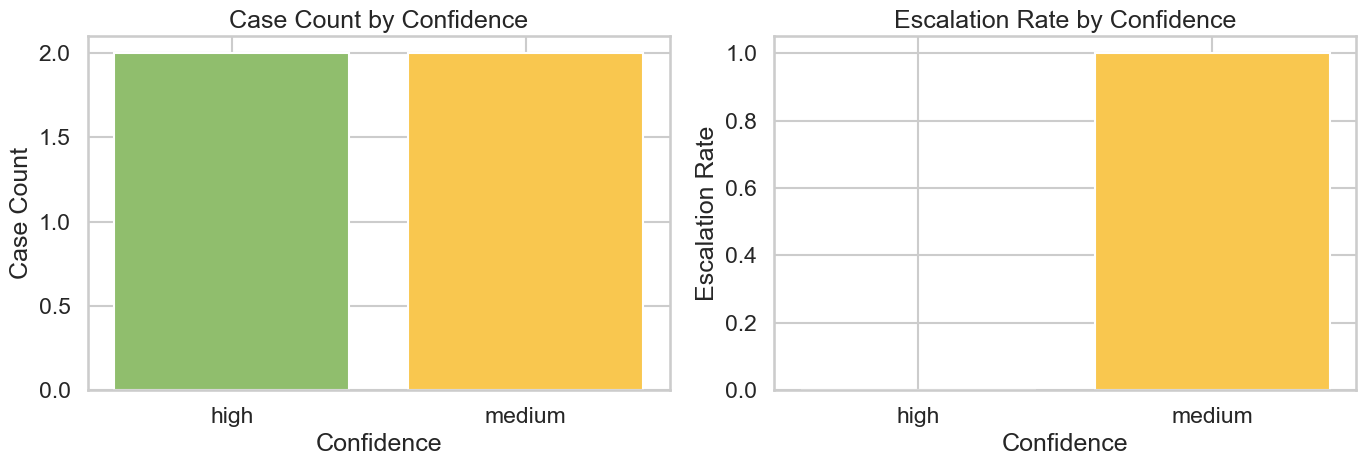

,confidence,cases,escalations,escalation_rate
0,high,2,0,0.0
1,medium,2,2,1.0


In [4]:
summary_df = (
    pipeline_results.groupby('confidence', as_index=False)
    .agg(
        cases=('case_id', 'count'),
        escalations=('requires_human_review', 'sum'),
    )
)
summary_df['escalation_rate'] = (summary_df['escalations'] / summary_df['cases']).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary_df['confidence'], summary_df['cases'], color=['#90BE6D', '#F9C74F', '#577590'])
axes[0].set_title('Case Count by Confidence')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Case Count')

axes[1].bar(summary_df['confidence'], summary_df['escalation_rate'], color=['#90BE6D', '#F9C74F', '#577590'])
axes[1].set_title('Escalation Rate by Confidence')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Escalation Rate')

plt.tight_layout()
plt.show()

display(summary_df)

## Section 5: Exercises

### Exercise 1: Report Schema Validator

Parse each generated report JSON and validate required keys for downstream pipelines.

In [5]:
required_keys = {'case_id', 'gene', 'alteration', 'tumor_type', 'evidence_note', 'confidence', 'requires_human_review', 'suggested_tool'}

def validate_report_schema(report_text: str) -> dict[str, object]:
    payload = json.loads(report_text)
    missing = sorted(required_keys - set(payload.keys()))
    return {'is_valid': len(missing) == 0, 'missing_keys': missing}

schema_rows = []
for _, row in pipeline_results.iterrows():
    if row['stage_report'] == 'escalate':
        schema_rows.append({'case_id': row['case_id'], 'is_valid': False, 'missing_keys': sorted(required_keys)})
        continue
    check = validate_report_schema(row['report_json'])
    schema_rows.append({'case_id': row['case_id'], **check})

schema_df = pd.DataFrame(schema_rows)
display(schema_df)

,case_id,is_valid,missing_keys
0,g_01,True,[]
1,g_02,True,[]
2,g_03,True,[]
3,g_04,True,[]


### Exercise 2: Specialist Agent Router

Assign each case to a specialist review lane using tumor type and confidence context.

In [6]:
def specialist_lane(row: pd.Series) -> str:
    if row['requires_human_review'] and row['confidence'] != 'high':
        return 'molecular_tumor_board_review'
    if row['suggested_tool'] == 'trial_matching':
        return 'translational_trials_lane'
    return 'standard_variant_lane'

routing_df = pipeline_results[['case_id', 'confidence', 'requires_human_review', 'suggested_tool']].copy()
routing_df['specialist_lane'] = routing_df.apply(specialist_lane, axis=1)

display(routing_df)
print('Specialist lane assignment completed for all cases.')

,case_id,confidence,requires_human_review,suggested_tool,specialist_lane
0,g_01,high,False,knowledge_base_lookup,standard_variant_lane
1,g_02,medium,True,cohort_portal_query,molecular_tumor_board_review
2,g_03,medium,True,literature_search,molecular_tumor_board_review
3,g_04,high,False,trial_matching,translational_trials_lane


Specialist lane assignment completed for all cases.


## Section 6: Key Takeaways

- Genomics agent workflows benefit from staged execution with explicit failure and escalation states.
- Confidence and review flags should be first-class outputs, not hidden in narrative text.
- Schema validation prevents fragile downstream integrations.
- Specialist lane routing supports safer human-in-the-loop decision support.
- Provenance-rich report objects make agent behavior auditable and reproducible.


## Next Steps

1. Add external evidence APIs and compare against this offline simulation.
2. Introduce conflict-detection logic for multi-source annotation disagreements.
3. Persist pipeline and routing outputs for Chapter 8 multi-agent coordination.
4. Extend lane routing with pediatric-specific governance constraints.


**Last Updated**: May 2026